# K-Nearest Neighbors (KNN)

**Definition:**

KNN (K-Nearest Neighbors) is a **supervised machine learning algorithm** used for both **classification** and **regression**.

It predicts the class/value of a new data point based on the **K nearest neighbors** from the training dataset.

---

## Working Steps of KNN

1. Choose the value of **K**.
2. Calculate the distance between the test point and all training points (usually Euclidean distance).
3. Select the **K nearest neighbors**.
4. For:

   * **Classification:** Use **majority voting**.
   * **Regression:** Take the **average** of K nearest values.
5. Assign the final prediction.

---

## Why is KNN called a Lazy Learner?

**Answer:**

KNN performs **no actual training**. It simply stores the training data and performs all computations during prediction time.

Therefore, it is called a **Lazy Learning Algorithm**.

---

## Why is KNN called an Instance-Based Learning Algorithm?

**Answer:**

Because predictions are made directly using the stored training instances rather than building a mathematical model.

Therefore, KNN is known as an **Instance-Based Learning Algorithm**.

---

## Why is KNN a Non-Parametric Algorithm?

**Answer:**

KNN does not assume any fixed probability distribution or functional form of the data.

Therefore, it is called a **Non-Parametric Algorithm**.

---

## Effect of K Value

### Small K (e.g., K = 1)

* Sensitive to noise
* High variance
* Can cause overfitting

### Large K

* High bias
* Can cause underfitting
* Smoother decision boundary

---

## Rule for Selecting K

A common rule is:

[
K = \sqrt{N}
]

Where:

* **N = Number of training samples**

Usually choose an **odd value of K** for binary classification to avoid ties.

---

## Distance Metrics Used in KNN

1. Euclidean Distance
2. Manhattan Distance
3. Minkowski Distance

**Euclidean Distance Formula:**

[
d = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
]

---

## Advantages of KNN

1. No training phase required.
2. Easy to understand and implement.
3. Effective on small datasets.
4. Naturally handles multiclass classification.
5. Can be used for both classification and regression.

---

## Disadvantages of KNN

1. Computationally expensive during prediction.
2. Memory intensive because it stores all training data.
3. Sensitive to noisy data and outliers.
4. Performance decreases in high-dimensional data (Curse of Dimensionality).
5. Requires feature scaling.

---

## Why is Feature Scaling Important in KNN?

**Answer:**

KNN is distance-based. Features with larger values can dominate the distance calculation.

Therefore, we use:

* Normalization
* Standardization

to bring all features to the same scale.

---

### 2-Line Interview Answer

**"KNN is a supervised, non-parametric, instance-based learning algorithm that classifies a new data point based on the majority class of its K nearest neighbors. It is called a lazy learner because it stores training data and performs computation only during prediction."**



In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/covid_toy - covid_toy.csv")
df.head()

,age,gender,fever,cough,city,has_covid
0,60,Male,103.0,Mild,Kolkata,No
1,27,Male,100.0,Mild,Delhi,Yes
2,42,Male,101.0,Mild,Delhi,No
3,31,Female,98.0,Mild,Kolkata,No
4,65,Female,101.0,Mild,Mumbai,No


In [ ]:
df['fever'] = df['fever'].fillna(df['fever'].mean())

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include=['object']):
  df[col] = le.fit_transform(df[col])

df.head()

,age,gender,fever,cough,city,has_covid
0,60,1,103.0,0,2,0
1,27,1,100.0,0,1,1
2,42,1,101.0,0,1,0
3,31,0,98.0,0,2,0
4,65,0,101.0,0,3,0


In [ ]:
x=df.drop(columns=['has_covid'])
y=df['has_covid']
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train,y_train)

y_pred=knn.predict(x_test)
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.525


#k-mean

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
df=pd.read_csv("/content/mall.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df=df.drop(columns=['CustomerID','Genre'])
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [ ]:
x=df.iloc[:,[0,2]].values

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
fig=px.scatter_3d(x=df['Age'],y=df['Annual Income (k$)'],z=df['Spending Score (1-100)'])
fig.show()

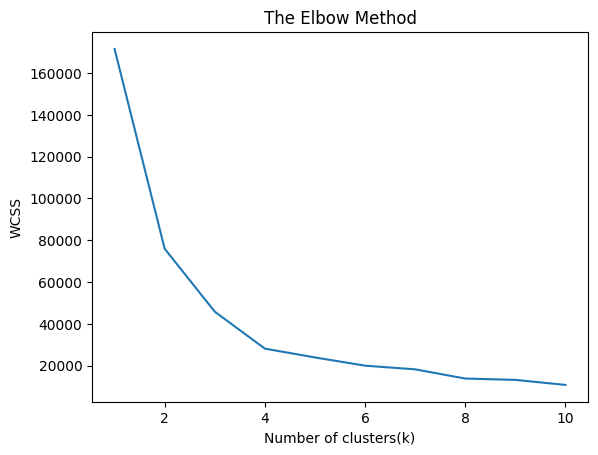

In [ ]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(x)
  wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters(k)')
plt.ylabel('WCSS')
plt.show()

From the above plot,we can see the elbow point is at 4. So the number of clusters here will be 4.

In [ ]:
kmeans=KMeans(n_clusters=4,init='k-means++',random_state=42)
y_predict=kmeans.fit_predict(x)

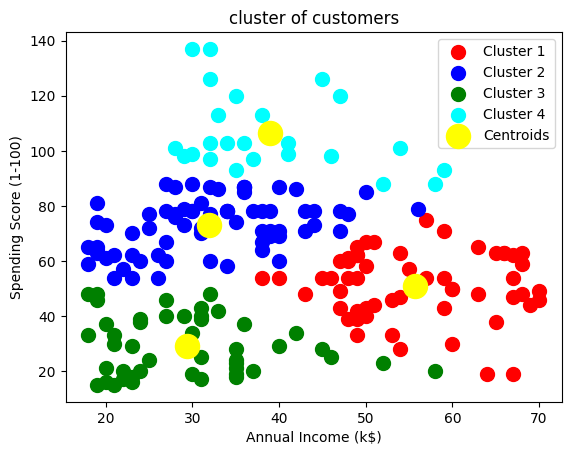

In [ ]:
#visulaizing the cluster
plt.scatter(x[y_predict==0,0],x[y_predict==0,1],s=100,c='red',label='Cluster 1')
plt.scatter(x[y_predict==1,0],x[y_predict==1,1],s=100,c='blue',label='Cluster 2')
plt.scatter(x[y_predict==2,0],x[y_predict==2,1],s=100,c='green',label='Cluster 3')
plt.scatter(x[y_predict==3,0],x[y_predict==3,1],s=100,c='cyan',label='Cluster 4')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=300,c='yellow',label='Centroids')
plt.title('cluster of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [1]:
fig=px.scatter_3d(df,x=df['Age'],y=df['Annual Income (k$)'],z=df['Spending Score (1-100)'],color=y_predict)
fig.show()

NameError: name 'px' is not defined